# DigiCow Farmer Training Adoption Challenge
## Improved Model with Feature Engineering + HistGradientBoosting

**Stratégie :**
- Utilisation du Prior.csv pour créer des features de taux d'adoption (target encoding)
- Feature engineering sur les topics, les dates, et les entités (trainer, county, ward...)
- HistGradientBoostingClassifier (supporte les NaN nativement)
- Prédiction des 3 targets séparément
- CV 5-fold pour évaluation robuste

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
import ast
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Chargement des données

In [2]:
train = pd.read_csv('Train.csv')
test  = pd.read_csv('Test.csv')
prior = pd.read_csv('Prior.csv')

print(f'Train: {train.shape}, Test: {test.shape}, Prior: {prior.shape}')
print(f'\nDistribution des targets dans Train:')
for t in ['adopted_within_07_days', 'adopted_within_90_days', 'adopted_within_120_days']:
    rate = train[t].mean()
    print(f'  {t}: {train[t].sum()} positifs ({rate:.2%})')

Train: (13536, 17), Test: (5621, 14), Prior: (44882, 17)

Distribution des targets dans Train:
  adopted_within_07_days: 153 positifs (1.13%)
  adopted_within_90_days: 214 positifs (1.58%)
  adopted_within_120_days: 302 positifs (2.23%)


## 2. Feature Engineering

Le Prior.csv est une "mine d'or" : il contient l'historique d'adoption de chaque fermier, trainer, groupe, etc.
On l'utilise pour calculer des **taux d'adoption historiques** (target encoding).

In [3]:
def parse_topics(x):
    """Parse la liste de topics depuis la colonne topics_list."""
    try:
        val = ast.literal_eval(str(x))
        flat = []
        for item in val:
            if isinstance(item, list): flat.extend(item)
            else: flat.append(item)
        return flat
    except:
        return []


def engineer_features(df, ref_df):
    """
    Crée des features enrichies.
    df : dataframe à transformer (train ou test)
    ref_df : Prior.csv, utilisé pour calculer les stats historiques
    """
    df = df.copy()
    
    # ── Features basées sur les topics ──────────────────────────────────────
    df['topics_parsed'] = df['topics_list'].apply(parse_topics)
    df['n_topics']        = df['topics_parsed'].apply(len)
    df['n_unique_topics'] = df['topics_parsed'].apply(lambda x: len(set(x)))
    
    # ── Features temporelles ─────────────────────────────────────────────────
    df['training_day'] = pd.to_datetime(df['training_day'], errors='coerce')
    df['day_of_week']  = df['training_day'].dt.dayofweek   # 0=Lundi, 6=Dimanche
    df['month']        = df['training_day'].dt.month
    df['day_of_month'] = df['training_day'].dt.day
    
    # ── Target encoding depuis le Prior ──────────────────────────────────────
    # Pour chaque entité (farmer, trainer, groupe, county, ward, subcounty)
    # on calcule le taux d'adoption historique dans le Prior
    group_entities = [
        ('farmer_name', 'farmer'),
        ('trainer',     'trainer'),
        ('group_name',  'group'),
        ('county',      'county'),
        ('ward',        'ward'),
        ('subcounty',   'subcounty'),
        ('registration','reg'),
        ('age',         'age'),
    ]
    
    for grp_col, prefix in group_entities:
        if grp_col not in ref_df.columns:
            continue
        stats = ref_df.groupby(grp_col).agg(
            **{f'{prefix}_cnt':    (grp_col, 'count'),
               f'{prefix}_rate07': ('adopted_within_07_days',  'mean'),
               f'{prefix}_rate90': ('adopted_within_90_days',  'mean'),
               f'{prefix}_rate120':('adopted_within_120_days', 'mean'),
            }
        ).reset_index()
        df = df.merge(stats, on=grp_col, how='left')
    
    # ── Label encoding des variables catégorielles ───────────────────────────
    cat_cols = ['gender', 'registration', 'age', 'county', 'subcounty',
                'ward', 'trainer', 'group_name']
    for c in cat_cols:
        le = LabelEncoder()
        # Fit sur toutes les valeurs connues (train+test+prior)
        all_vals = pd.concat([ref_df[c], df[c]]).astype(str).unique()
        le.fit(all_vals)
        df[c + '_enc'] = le.transform(df[c].astype(str))
    
    return df


# Appliquer le feature engineering
train_fe = engineer_features(train, prior)
test_fe  = engineer_features(test,  prior)

print('Feature engineering terminé.')
print(f'Nouvelles colonnes: {train_fe.shape[1] - train.shape[1]}')

Feature engineering terminé.
Nouvelles colonnes: 46


In [4]:
# Définir les features d'entraînement
FEATURE_COLS = [
    # Encodages catégoriels
    'gender_enc', 'registration_enc', 'age_enc', 'county_enc',
    'subcounty_enc', 'ward_enc', 'trainer_enc', 'group_name_enc',
    # Features numériques brutes
    'belong_to_cooperative', 'has_topic_trained_on',
    'n_topics', 'n_unique_topics',
    # Features temporelles
    'day_of_week', 'month', 'day_of_month',
    # Target encoding : farmer
    'farmer_cnt', 'farmer_rate07', 'farmer_rate90', 'farmer_rate120',
    # Target encoding : trainer
    'trainer_cnt', 'trainer_rate07', 'trainer_rate90', 'trainer_rate120',
    # Target encoding : groupe
    'group_cnt', 'group_rate07', 'group_rate90', 'group_rate120',
    # Target encoding : county
    'county_cnt', 'county_rate07', 'county_rate90',
    # Target encoding : ward
    'ward_cnt', 'ward_rate07',
    # Target encoding : subcounty
    'subcounty_cnt', 'subcounty_rate07',
    # Target encoding : registration et age
    'reg_rate07', 'reg_rate90',
    'age_rate07', 'age_rate90',
]

# Garder seulement les colonnes qui existent
FEATURE_COLS = [c for c in FEATURE_COLS if c in train_fe.columns]
print(f'Nombre de features utilisées: {len(FEATURE_COLS)}')

Nombre de features utilisées: 38


## 3. Entraînement avec validation croisée (5-fold)

On entraîne un modèle séparé pour chacune des 3 targets.

In [5]:
TARGETS = [
    ('adopted_within_07_days',  'Target_07'),
    ('adopted_within_90_days',  'Target_90'),
    ('adopted_within_120_days', 'Target_120'),
]

X_train = train_fe[FEATURE_COLS].values
X_test  = test_fe[FEATURE_COLS].values

oof_predictions  = {}
test_predictions = {}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for target_col, target_name in TARGETS:
    y = train_fe[target_col].values
    oof  = np.zeros(len(y))
    test_preds = np.zeros(len(X_test))
    
    pos = (y == 1).sum()
    neg = (y == 0).sum()
    pos_weight = neg / pos  # Rééquilibrage pour les classes déséquilibrées
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        
        model = HistGradientBoostingClassifier(
            max_iter=400,
            learning_rate=0.05,
            max_depth=5,
            min_samples_leaf=15,
            random_state=42,
            class_weight={0: 1, 1: pos_weight}
        )
        model.fit(X_tr, y_tr)
        
        oof[val_idx]   = model.predict_proba(X_val)[:, 1]
        test_preds    += model.predict_proba(X_test)[:, 1] / 5
    
    oof_predictions[target_name]  = oof
    test_predictions[target_name] = test_preds
    
    ll  = log_loss(y, oof)
    auc = roc_auc_score(y, oof)
    weighted_score = 0.75 * (1/(1+ll)) + 0.25 * auc
    print(f'{target_name}: LogLoss={ll:.4f} | AUC={auc:.4f}')

Target_07: LogLoss=0.1110 | AUC=0.9807
Target_90: LogLoss=0.1060 | AUC=0.9708
Target_120: LogLoss=0.1212 | AUC=0.9792


## 4. Création du fichier de soumission

In [6]:
ss = pd.read_csv('SampleSubmission.csv')
print('Colonnes SampleSubmission:', ss.columns.tolist())
ss.head(2)

Colonnes SampleSubmission: ['ID', 'Target_07_AUC', 'Target_90_AUC', 'Target_120_AUC', 'Target_07_LogLoss', 'Target_90_LogLoss', 'Target_120_LogLoss']


,ID,Target_07_AUC,Target_90_AUC,Target_120_AUC,Target_07_LogLoss,Target_90_LogLoss,Target_120_LogLoss
0,ID_LEG1GM,0,0,0,0,0,0
1,ID_1UKOKW,0,0,0,0,0,0


In [7]:
# Remplir le fichier de soumission
# Les colonnes AUC et LogLoss reçoivent les mêmes probabilités
ss['Target_07_AUC']     = test_predictions['Target_07']
ss['Target_07_LogLoss'] = test_predictions['Target_07']
ss['Target_90_AUC']     = test_predictions['Target_90']
ss['Target_90_LogLoss'] = test_predictions['Target_90']
ss['Target_120_AUC']    = test_predictions['Target_120']
ss['Target_120_LogLoss']= test_predictions['Target_120']

# Colonnes génériques (si présentes)
if 'Target_LogLoss' in ss.columns:
    ss['Target_LogLoss'] = test_predictions['Target_07']
if 'Target_AUC' in ss.columns:
    ss['Target_AUC'] = test_predictions['Target_07']

ss.to_csv('ImprovedSubmission.csv', index=False)
print('Fichier sauvegardé: ImprovedSubmission.csv')
ss.head()

Fichier sauvegardé: ImprovedSubmission.csv


,ID,Target_07_AUC,Target_90_AUC,Target_120_AUC,Target_07_LogLoss,Target_90_LogLoss,Target_120_LogLoss
0,ID_LEG1GM,0.033452,0.016187,0.012964,0.033452,0.016187,0.012964
1,ID_1UKOKW,0.035400,0.032437,0.036632,0.035400,0.032437,0.036632
2,ID_U5H2YK,0.244911,0.418622,0.530247,0.244911,0.418622,0.530247
3,ID_55957A,0.228171,0.415106,0.529126,0.228171,0.415106,0.529126
4,ID_N1AC0A,0.033042,0.012914,0.012910,0.033042,0.012914,0.012910


## 5. Analyse des résultats OOF (Out-of-Fold)

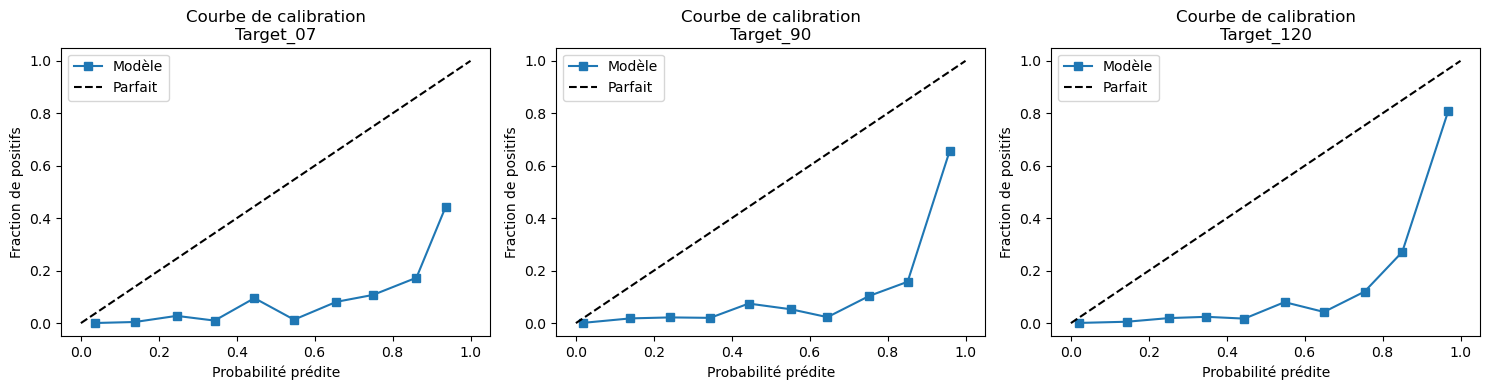

Graphique sauvegardé.


In [8]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (target_col, target_name) in zip(axes, TARGETS):
    y = train_fe[target_col].values
    preds = oof_predictions[target_name]
    
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y, preds, n_bins=10
    )
    ax.plot(mean_predicted_value, fraction_of_positives, 's-', label='Modèle')
    ax.plot([0, 1], [0, 1], 'k--', label='Parfait')
    ax.set_xlabel('Probabilité prédite')
    ax.set_ylabel('Fraction de positifs')
    ax.set_title(f'Courbe de calibration\n{target_name}')
    ax.legend()

plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé.')

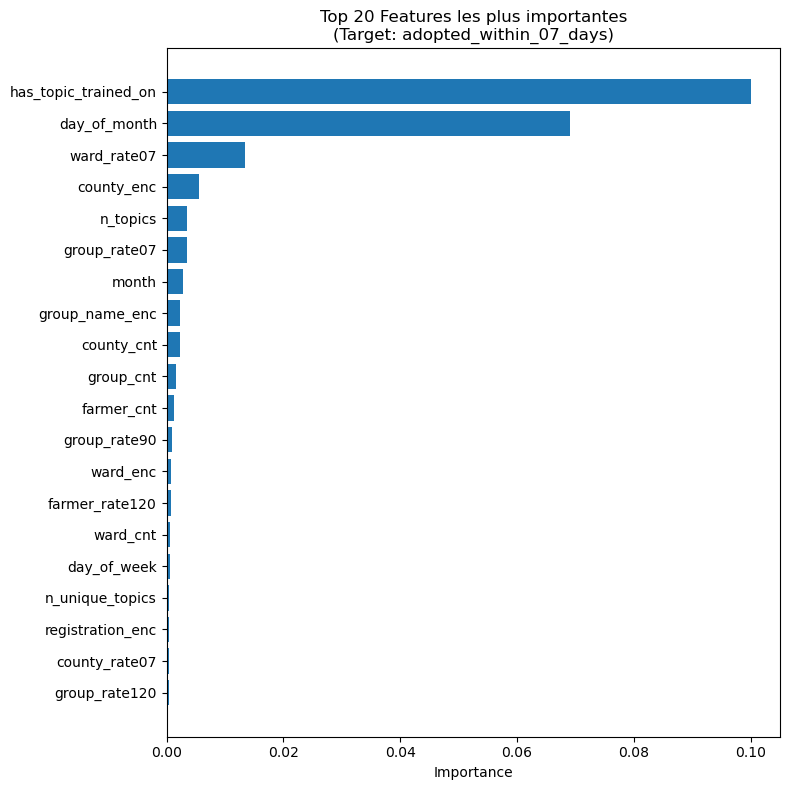

In [11]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Permutation importance sur le train ou validation set
result = permutation_importance(final_model, X_train, y, n_repeats=10, random_state=42, scoring='roc_auc')

importances = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': result.importances_mean
}).sort_values('importance', ascending=True).tail(20)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(importances['feature'], importances['importance'])
ax.set_title('Top 20 Features les plus importantes\n(Target: adopted_within_07_days)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()